# Task 1

### Importing Libraries

In [2]:
import numpy
import torch
import torch.nn as nn
import torch.optim as optim
import types
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE

if torch.cuda.is_available() == True:
    device = 'cuda'
else:
    device = 'cpu'

print(f'device: {device}')

from google.colab import drive
drive.mount('/content/drive')

device: cuda
Mounted at /content/drive


# Task 1.1

### Dataset Download

In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

cifar_10_training = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=True, transform=transform, download=True)
cifar_10_validation = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=False, transform=transform, download=True)

train_dataloder = DataLoader(cifar_10_training, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(cifar_10_validation, batch_size=64, shuffle=False)


### Replacing classification layer + training loop

In [5]:
EPOCHS=5

resnet_pretrained = models.resnet152(weights='DEFAULT')

resnet_pretrained.fc = nn.Linear(in_features=resnet_pretrained.fc.in_features, out_features=10)

for param in resnet_pretrained.parameters():
    param.requires_grad = False

for param in resnet_pretrained.fc.parameters():
    param.requires_grad = True

resnet_pretrained = resnet_pretrained.to(device)

training_loss = []
training_accuracy = []
validation_loss = []
validation_accuracy = []

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_pretrained.parameters(), lr=0.01)

for i in range(EPOCHS):
    print(f'epoch: {i}')

    resnet_pretrained.train()
    curr_training_loss = 0
    curr_training_accuracy = 0

    for image, label in train_dataloder:
        image = image.to(device)
        label = label.to(device)
        optimizer.zero_grad()

        prediction = resnet_pretrained(image)
        predicted_labels = prediction.argmax(dim=1)

        curr_loss = loss(prediction, label)

        curr_training_loss += curr_loss.item()
        curr_training_accuracy += accuracy_score(label.detach().cpu().numpy(), predicted_labels.detach().cpu().numpy()) * 100

        curr_loss.backward()

        optimizer.step()

    training_loss.append(curr_training_loss/len(train_dataloder))
    training_accuracy.append(curr_training_accuracy/len(train_dataloder))
    print(f'training loss (baseline): {curr_training_loss/len(train_dataloder)}')
    print(f'training accuracy (baseline): {curr_training_accuracy/len(train_dataloder)}% \n')

    resnet_pretrained.eval()
    curr_validation_loss = 0
    curr_validation_accuracy = 0

    with torch.no_grad():
        for image, label in validation_dataloader:
            image = image.to(device)
            label = label.to(device)

            prediction = resnet_pretrained(image)
            predicted_labels = prediction.argmax(dim=1)

            curr_loss = loss(prediction, label)

            curr_validation_loss += curr_loss.item()
            curr_validation_accuracy += accuracy_score(label.detach().cpu().numpy(), predicted_labels.detach().cpu().numpy()) * 100

    validation_loss.append(curr_validation_loss/len(validation_dataloader))
    validation_accuracy.append(curr_validation_accuracy/len(validation_dataloader))
    print(f'validation loss (baseline): {curr_validation_loss/len(validation_dataloader)}')
    print(f'validation accuracy (baseline): {curr_validation_accuracy/len(validation_dataloader)}% \n')



epoch: 0
training loss (baseline): 1.0577722748222254
training accuracy (baseline): 74.33264066496163% 

validation loss (baseline): 0.7445921271469942
validation accuracy (baseline): 78.75199044585987% 

epoch: 1
training loss (baseline): 0.6832228736651828
training accuracy (baseline): 79.30986253196932% 

validation loss (baseline): 0.6344562279190987
validation accuracy (baseline): 80.23487261146497% 

epoch: 2
training loss (baseline): 0.6180803236144278
training accuracy (baseline): 80.66456202046035% 

validation loss (baseline): 0.590303229488385
validation accuracy (baseline): 81.53861464968153% 

epoch: 3
training loss (baseline): 0.5834657105872089
training accuracy (baseline): 81.43781969309462% 

validation loss (baseline): 0.5747900250231385
validation accuracy (baseline): 81.75756369426752% 

epoch: 4
training loss (baseline): 0.5594372630805311
training accuracy (baseline): 82.0192615089514% 

validation loss (baseline): 0.5453460585729332
validation accuracy (baseline)

### Visualization for Task 1.1

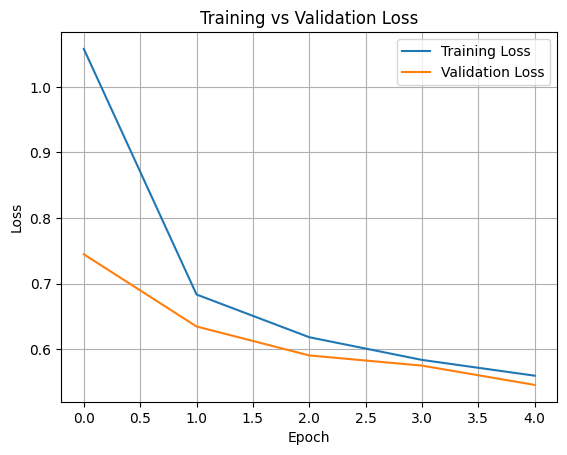

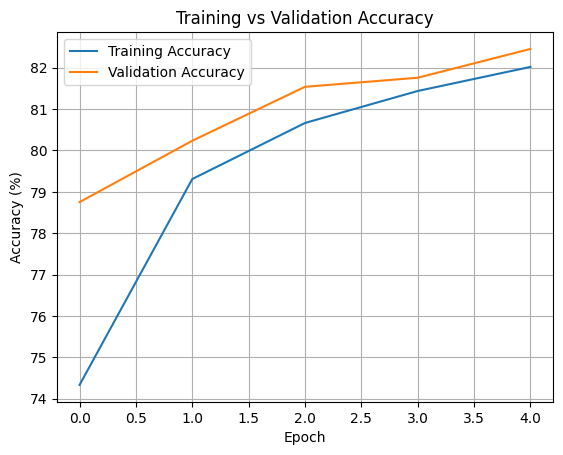

In [6]:
plt.figure()
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.figure()
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid()
plt.legend()

plt.show()

# Task 1.2

### Downloading dataset

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

cifar_10_training = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=True, transform=transform, download=True)
cifar_10_validation = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=False, transform=transform, download=True)

train_dataloder = DataLoader(cifar_10_training, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(cifar_10_validation, batch_size=64, shuffle=False)

### Training while disabling residual connections

In [ ]:
def replace_block(block, x):
    return block.relu(block.bn3(block.conv3(block.relu(block.bn2(block.conv2(block.relu(block.bn1(block.conv1(x)))))))))

EPOCHS=5

resnet_pretrained = models.resnet152(weights='DEFAULT')

resnet_pretrained.fc = nn.Linear(in_features=resnet_pretrained.fc.in_features, out_features=10)

for param in resnet_pretrained.parameters():
    param.requires_grad = False

for param in resnet_pretrained.fc.parameters():
    param.requires_grad = True

#replacing blocks with no skip connection
block1 = resnet_pretrained.layer2[2]
block2 = resnet_pretrained.layer3[3]
block3 = resnet_pretrained.layer4[1]
block4 = resnet_pretrained.layer4[2]

block1.forward = types.MethodType(replace_block, block1)
block2.forward = types.MethodType(replace_block, block2)
block3.forward = types.MethodType(replace_block, block3)
block4.forward = types.MethodType(replace_block, block4)
#replacing blocks with no skip connection

resnet_pretrained = resnet_pretrained.to(device)

training_loss_skip = []
validation_loss_skip = []
training_accuracy_skip = []
validation_accuracy_skip = []

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_pretrained.parameters(), lr=0.01)

for i in range(EPOCHS):
    print(f'epoch: {i} \n')

    resnet_pretrained.train()
    curr_training_loss = 0
    curr_training_accuracy = 0

    for image, label in train_dataloder:
        image = image.to(device)
        label = label.to(device)
        optimizer.zero_grad()

        prediction = resnet_pretrained(image)
        predicted_label = prediction.argmax(dim=1)

        curr_loss = loss(prediction, label)

        curr_training_loss += curr_loss.item()
        curr_training_accuracy += accuracy_score(label.cpu().numpy(), predicted_label.cpu().numpy())

        curr_loss.backward()

        optimizer.step()

    training_loss_skip.append(curr_training_loss/len(train_dataloder))
    training_accuracy_skip.append((curr_training_accuracy/len(train_dataloder))*100)
    print(f'training loss with no residual connections: {curr_training_loss/len(train_dataloder)}')
    print(f'training accuracy with no residual connections: {(curr_training_accuracy/len(train_dataloder))*100}% \n')

    resnet_pretrained.eval()
    curr_validation_loss = 0
    curr_validation_accuracy = 0

    with torch.no_grad():
        for image, label in validation_dataloader:
            image = image.to(device)
            label = label.to(device)

            prediction = resnet_pretrained(image)
            predicted_label = prediction.argmax(dim=1)

            curr_loss = loss(prediction, label)

            curr_validation_loss += curr_loss.item()
            curr_validation_accuracy += accuracy_score(label.cpu().numpy(), predicted_label.cpu().numpy())

    validation_loss_skip.append(curr_validation_loss/len(validation_dataloader))
    validation_accuracy_skip.append((curr_validation_accuracy/len(validation_dataloader))*100)
    print(f'validation loss with no residual connections: {curr_validation_loss/len(validation_dataloader)}')
    print(f'validation accuracy with no residual connections: {(curr_validation_accuracy/len(validation_dataloader))*100}% \n')



epoch: 0 

training loss with no residual connections: 2.3026352474451675
training accuracy with no residual connections: 10.07632672634271% 

validation loss with no residual connections: 2.631963599259686
validation accuracy with no residual connections: 10.171178343949045% 

epoch: 1 

training loss with no residual connections: 2.3024693462244996
training accuracy with no residual connections: 9.986413043478262% 

validation loss with no residual connections: 2.3496565013934094
validation accuracy with no residual connections: 9.96218152866242% 

epoch: 2 

training loss with no residual connections: 2.302352542462556
training accuracy with no residual connections: 10.252157928388748% 

validation loss with no residual connections: 2.4913011569126398
validation accuracy with no residual connections: 10.638933121019107% 

epoch: 3 

training loss with no residual connections: 2.302135262038092
training accuracy with no residual connections: 10.302109974424553% 

validation loss with

### Visualizing Task 1.2

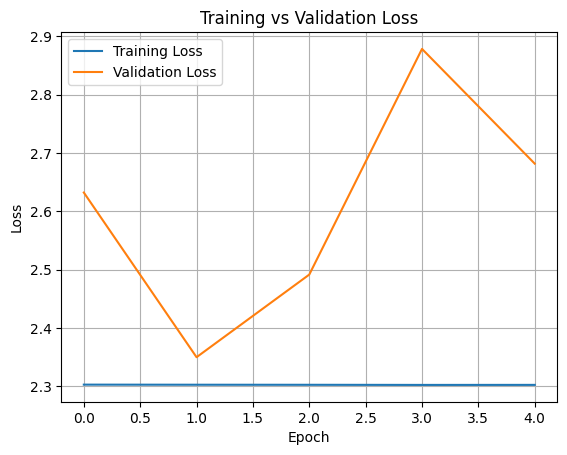

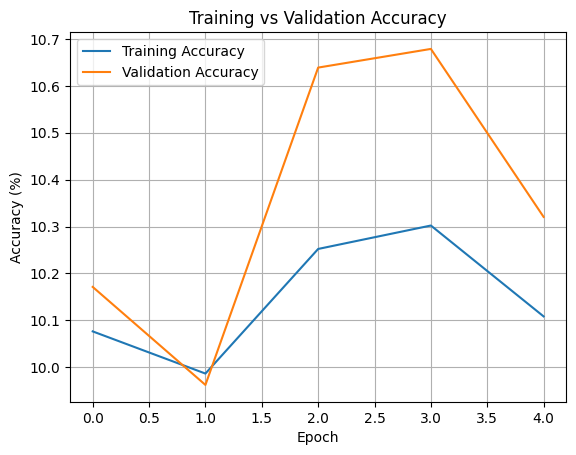

In [ ]:
plt.figure()
plt.plot(training_loss_skip, label='Training Loss')
plt.plot(validation_loss_skip, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.figure()
plt.plot(training_accuracy_skip, label='Training Accuracy')
plt.plot(validation_accuracy_skip, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid()
plt.legend()



plt.show()

# Task 1.3

### Download CIFAR-10 data

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

cifar_10_training = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=True, transform=transform, download=True)
cifar_10_validation = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=False, transform=transform, download=True)

train_dataloder = DataLoader(cifar_10_training, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(cifar_10_validation, batch_size=64, shuffle=False)

### Collecting coordinates using TSNE

In [ ]:
layer1_features = []
layer3_features = []
layer4_features = []
labels = []

def hook_collect_layer1(module, input, output):
    layer1_features.append(output.detach().cpu())

def hook_collect_layer3(module, input, output):
    layer3_features.append(output.detach().cpu())

def hook_collect_layer4(module, input, output):
    layer4_features.append(output.detach().cpu())

resnet_pretrained = models.resnet152(weights='DEFAULT').to(device)
resnet_pretrained.layer1.register_forward_hook(hook_collect_layer1)
resnet_pretrained.layer3.register_forward_hook(hook_collect_layer3)
resnet_pretrained.layer4.register_forward_hook(hook_collect_layer4)

curr_batch = 0

with torch.no_grad():
  for image, label in train_dataloder:
      image = image.to(device)
      label = label.to(device)

      if curr_batch == 5:
          break

      prediction = resnet_pretrained(image)
      labels.append(label)

      curr_batch += 1

layer1_tensor = torch.cat(layer1_features, dim=0)
layer3_tensor = torch.cat(layer3_features, dim=0)
layer4_tensor = torch.cat(layer4_features, dim=0)
labels_tensor = torch.cat(labels, dim=0)

layer1_tensor_flattened = layer1_tensor.mean(dim=(2,3))
layer3_tensor_flattened = layer3_tensor.mean(dim=(2,3))
layer4_tensor_flattened = layer4_tensor.mean(dim=(2,3))

tsne = TSNE(perplexity=10, random_state=42)

layer1_coordinates = tsne.fit_transform(layer1_tensor_flattened)
layer3_coordinates = tsne.fit_transform(layer3_tensor_flattened)
layer4_coordinates = tsne.fit_transform(layer4_tensor_flattened)
labels = labels_tensor.cpu().numpy()


### Visualizing early, middle and late features

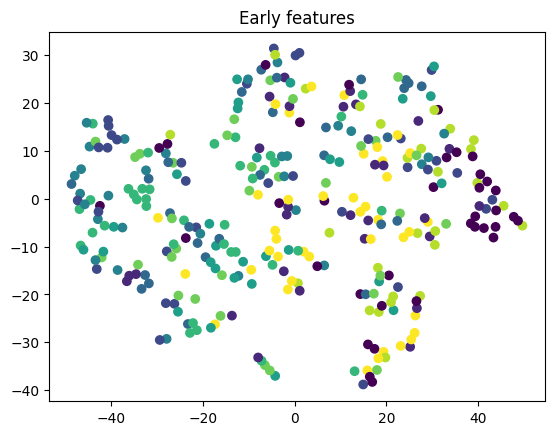

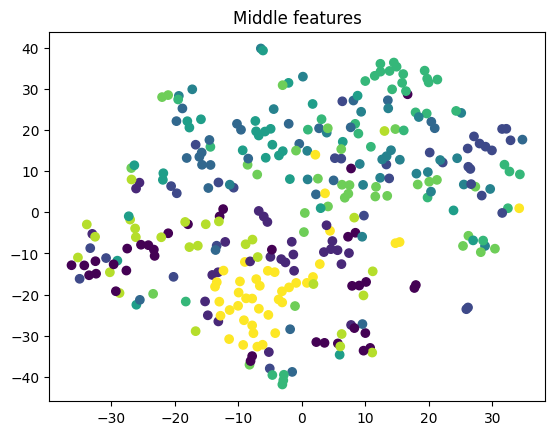

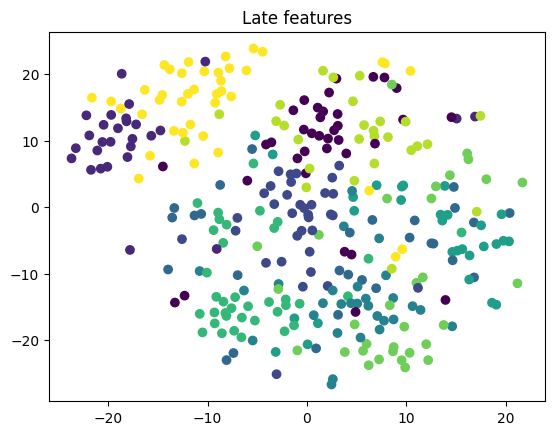

In [ ]:
plt.figure()
plt.scatter(layer1_coordinates[:,0], layer1_coordinates[:,1], c=labels)
plt.title('Early features')

plt.figure()
plt.scatter(layer3_coordinates[:,0], layer3_coordinates[:,1], c=labels)
plt.title('Middle features')

plt.figure()
plt.scatter(layer4_coordinates[:,0], layer4_coordinates[:,1], c=labels)
plt.title('Late features')
plt.show()



# Task 1.4

### Download CIFAR-10 data

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

cifar_10_training = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=True, transform=transform, download=True)
cifar_10_validation = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=False, transform=transform, download=True)

train_dataloader = DataLoader(cifar_10_training, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(cifar_10_validation, batch_size=64, shuffle=False)

### 1) Finetune complete model (using pretrained weights)

In [ ]:
EPOCHS = 5

resnet_pretrained = models.resnet152(weights='DEFAULT')

resnet_pretrained.fc = nn.Linear(in_features=resnet_pretrained.fc.in_features, out_features=10)

resnet_pretrained = resnet_pretrained.to(device)

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_pretrained.parameters(), lr=0.01)

training_loss = []
validation_loss = []
training_accuracy = []
validation_accuracy = []

for i in range(EPOCHS):
    print(f'epoch: {i} \n')

    resnet_pretrained.train()

    curr_training_loss = 0
    curr_training_accuracy = 0

    for image, label in train_dataloader:
        optimizer.zero_grad()
        image = image.to(device)
        label = label.to(device)

        prediction = resnet_pretrained(image)
        predicted_label = prediction.argmax(dim=1)

        curr_loss = loss(prediction, label)
        curr_training_loss += curr_loss.item()
        curr_training_accuracy += accuracy_score(label.cpu().numpy(), predicted_label.cpu().numpy())

        curr_loss.backward()

        optimizer.step()

    training_loss.append(curr_training_loss/len(train_dataloader))
    training_accuracy.append((curr_training_accuracy/len(train_dataloader))*100)
    print(f'training loss on complete model (pretrained): {curr_training_loss/len(train_dataloader)}')
    print(f'training accuracy on complete model (pretrained): {(curr_training_accuracy/len(train_dataloader))*100} \n')

    resnet_pretrained.eval()

    curr_validation_loss = 0
    curr_validation_accuracy = 0

    with torch.no_grad():
        for image, label in validation_dataloader:
            image = image.to(device)
            label = label.to(device)

            prediction = resnet_pretrained(image)
            predicted_label = prediction.argmax(dim=1)

            curr_loss = loss(prediction, label)
            curr_validation_loss += curr_loss.item()
            curr_validation_accuracy += accuracy_score(label.cpu().numpy(), predicted_label.cpu().numpy())

    validation_loss.append(curr_validation_loss/len(validation_dataloader))
    validation_accuracy.append((curr_validation_accuracy/len(validation_dataloader))*100)
    print(f'validation loss on complete model (pretrained): {curr_validation_loss/len(validation_dataloader)}')
    print(f'validation accuracy on complete model (pretrained): {(curr_validation_accuracy/len(validation_dataloader))*100}')



Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:02<00:00, 104MB/s]


epoch: 0 

training loss on complete model (pretrained): 0.4625875045452505
training accuracy on complete model (pretrained): 87.46203644501279 

validation loss on complete model (pretrained): 0.1583927313138725
validation accuracy on complete model (pretrained): 94.91441082802548
epoch: 1 

training loss on complete model (pretrained): 0.10875903273029897
training accuracy on complete model (pretrained): 96.49936061381074 

validation loss on complete model (pretrained): 0.11038922271720923
validation accuracy on complete model (pretrained): 96.34753184713377
epoch: 2 

training loss on complete model (pretrained): 0.0590003826643538
training accuracy on complete model (pretrained): 98.12380115089513 

validation loss on complete model (pretrained): 0.0882842113252041
validation accuracy on complete model (pretrained): 97.16361464968153
epoch: 3 



KeyboardInterrupt: 

### Visualizing loss and accuracy

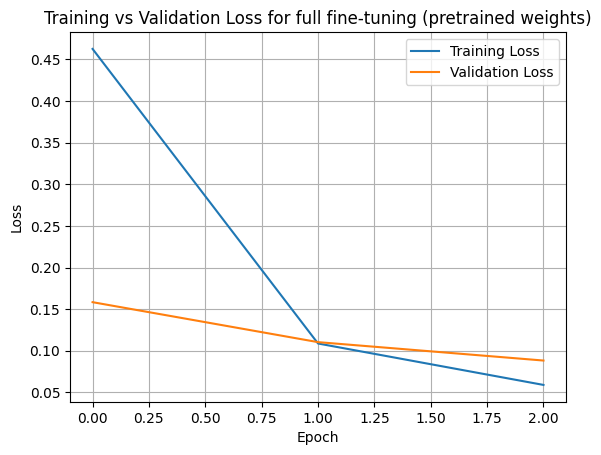

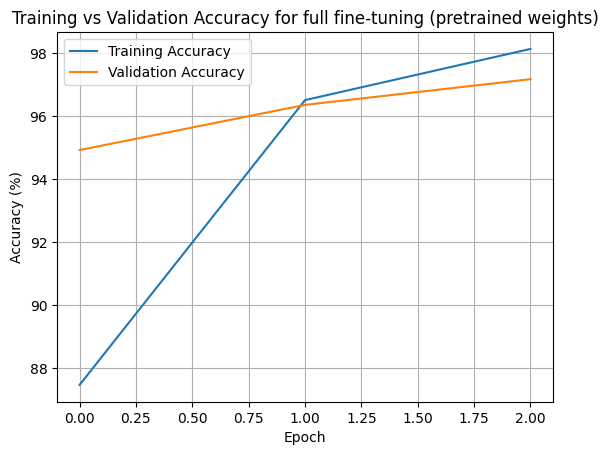

In [ ]:
plt.figure()
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Training vs Validation Loss for full fine-tuning (pretrained weights)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.figure()
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy for full fine-tuning (pretrained weights)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid()
plt.legend()

plt.show()

### 2) Fine-tune complete model (using random initialization)

In [ ]:
EPOCHS = 3

resnet = models.resnet152(weights=None)

resnet.fc = nn.Linear(in_features=resnet.fc.in_features, out_features=10)

resnet= resnet.to(device)

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet.parameters(), lr=0.01)

training_loss = []
validation_loss = []
training_accuracy = []
validation_accuracy = []

for i in range(EPOCHS):
    print(f'epoch: {i} \n')

    resnet.train()

    curr_training_loss = 0
    curr_training_accuracy = 0

    for image, label in train_dataloader:
        optimizer.zero_grad()
        image = image.to(device)
        label = label.to(device)

        prediction = resnet(image)
        predicted_label = prediction.argmax(dim=1)

        curr_loss = loss(prediction, label)
        curr_training_loss += curr_loss.item()
        curr_training_accuracy += accuracy_score(label.cpu().numpy(), predicted_label.cpu().numpy())

        curr_loss.backward()

        optimizer.step()

    training_loss.append(curr_training_loss/len(train_dataloader))
    training_accuracy.append((curr_training_accuracy/len(train_dataloader))*100)
    print(f'training loss on complete model (random): {curr_training_loss/len(train_dataloader)}')
    print(f'training accuracy on complete model (random): {(curr_training_accuracy/len(train_dataloader))*100}% \n')

    resnet.eval()

    curr_validation_loss = 0
    curr_validation_accuracy = 0

    with torch.no_grad():
        for image, label in validation_dataloader:
            image = image.to(device)
            label = label.to(device)

            prediction = resnet(image)
            predicted_label = prediction.argmax(dim=1)

            curr_loss = loss(prediction, label)
            curr_validation_loss += curr_loss.item()
            curr_validation_accuracy += accuracy_score(label.cpu().numpy(), predicted_label.cpu().numpy())

    validation_loss.append(curr_validation_loss/len(validation_dataloader))
    validation_accuracy.append((curr_validation_accuracy/len(validation_dataloader))*100)
    print(f'validation loss on complete model (random): {curr_validation_loss/len(validation_dataloader)}')
    print(f'validation accuracy on complete model (random): {(curr_validation_accuracy/len(validation_dataloader))*100}% \n')



epoch: 0 

training loss on complete model (random): 2.2419243878720665
training accuracy on complete model (random): 19.11764705882353% 

validation loss on complete model (random): 2.132715500843753
validation accuracy on complete model (random): 23.54697452229299% 

epoch: 1 

training loss on complete model (random): 1.813895871419736
training accuracy on complete model (random): 31.627637468030688% 

validation loss on complete model (random): 2.414368152618408
validation accuracy on complete model (random): 25.348328025477706% 

epoch: 2 

training loss on complete model (random): 1.62738728187883
training accuracy on complete model (random): 39.77981138107417% 

validation loss on complete model (random): 1.9052478743206924
validation accuracy on complete model (random): 31.628184713375795% 



### Visualizing loss and accuracy

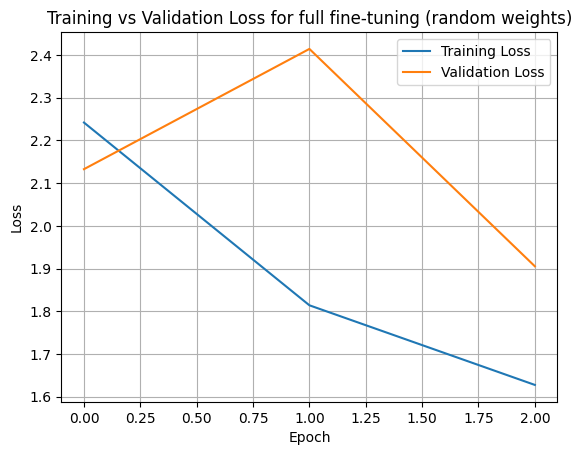

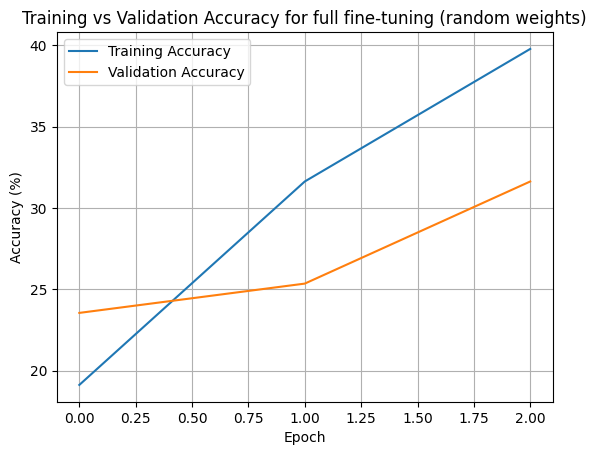

In [ ]:
plt.figure()
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Training vs Validation Loss for full fine-tuning (random weights)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.figure()
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy for full fine-tuning (random weights)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid()
plt.legend()

plt.show()

### 3) Fine-tune final block (using pretrained weights)

In [ ]:
EPOCHS = 3

resnet_pretrained = models.resnet152(weights='DEFAULT')

resnet_pretrained.fc = nn.Linear(in_features=resnet_pretrained.fc.in_features, out_features=10)

for param in resnet_pretrained.parameters():
    param.requires_grad = False

for param in resnet_pretrained.layer4[-1].parameters():
    param.requires_grad = True

for param in resnet_pretrained.fc.parameters():
    param.requires_grad = True

resnet_pretrained = resnet_pretrained.to(device)

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_pretrained.parameters(), lr=0.01)

training_loss = []
validation_loss = []
training_accuracy = []
validation_accuracy = []

for i in range(EPOCHS):
    print(f'epoch: {i} \n')

    resnet_pretrained.train()

    curr_training_loss = 0
    curr_training_accuracy = 0

    for image, label in train_dataloader:
        optimizer.zero_grad()
        image = image.to(device)
        label = label.to(device)

        prediction = resnet_pretrained(image)
        predicted_label = prediction.argmax(dim=1)

        curr_loss = loss(prediction, label)
        curr_training_loss += curr_loss.item()
        curr_training_accuracy += accuracy_score(label.cpu().numpy(), predicted_label.cpu().numpy())

        curr_loss.backward()

        optimizer.step()

    training_loss.append(curr_training_loss/len(train_dataloader))
    training_accuracy.append((curr_training_accuracy/len(train_dataloader))*100)
    print(f'training loss on final block (pretrained): {curr_training_loss/len(train_dataloader)}')
    print(f'training accuracy on final block (pretrained): {(curr_training_accuracy/len(train_dataloader))*100} \n')

    resnet_pretrained.eval()

    curr_validation_loss = 0
    curr_validation_accuracy = 0

    with torch.no_grad():
        for image, label in validation_dataloader:
            image = image.to(device)
            label = label.to(device)

            prediction = resnet_pretrained(image)
            predicted_label = prediction.argmax(dim=1)

            curr_loss = loss(prediction, label)
            curr_validation_loss += curr_loss.item()
            curr_validation_accuracy += accuracy_score(label.cpu().numpy(), predicted_label.cpu().numpy())

    validation_loss.append(curr_validation_loss/len(validation_dataloader))
    validation_accuracy.append((curr_validation_accuracy/len(validation_dataloader))*100)
    print(f'validation loss on final block (pretrained): {curr_validation_loss/len(validation_dataloader)}')
    print(f'validation accuracy on final block (pretrained): {(curr_validation_accuracy/len(validation_dataloader))*100}')



epoch: 0 

training loss on final block (pretrained): 0.9321358504197786
training accuracy on final block (pretrained): 74.9440537084399 

validation loss on final block (pretrained): 0.596910457322552
validation accuracy on final block (pretrained): 80.77229299363057
epoch: 1 

training loss on final block (pretrained): 0.5671538643519897
training accuracy on final block (pretrained): 81.28396739130434 

validation loss on final block (pretrained): 0.5150526000815592
validation accuracy on final block (pretrained): 82.96178343949045
epoch: 2 

training loss on final block (pretrained): 0.5054650169504268
training accuracy on final block (pretrained): 83.06226023017904 

validation loss on final block (pretrained): 0.4760654250717467
validation accuracy on final block (pretrained): 84.17595541401273


### Visualizing loss vs accuracy

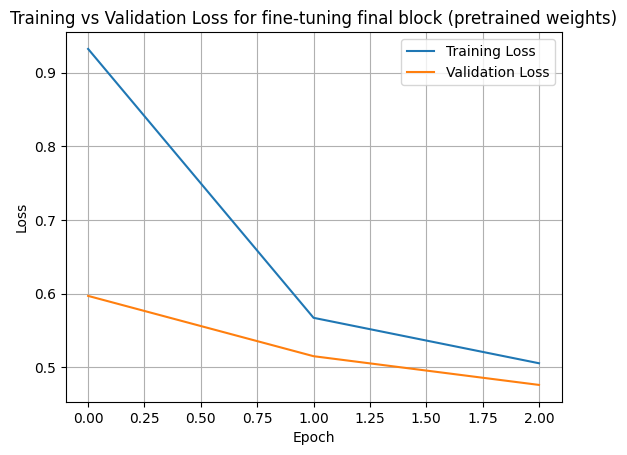

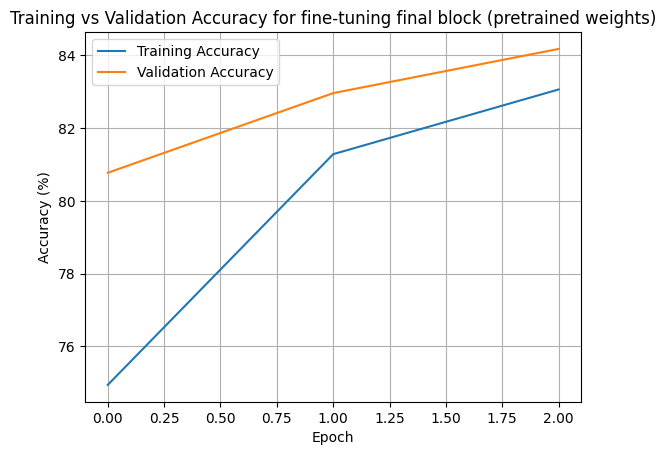

In [ ]:
plt.figure()
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Training vs Validation Loss for fine-tuning final block (pretrained weights)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.figure()
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy for fine-tuning final block (pretrained weights)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid()
plt.legend()

plt.show()

### 4) Fine-tune final block (using random initialization)

In [ ]:
EPOCHS = 3

resnet = models.resnet152(weights=None)

resnet.fc = nn.Linear(in_features=resnet.fc.in_features, out_features=10)

for param in resnet.parameters():
    param.requires_grad = False

for param in resnet.layer4[-1].parameters():
    param.requires_grad = True

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet = resnet.to(device)

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet.parameters(), lr=0.01)

training_loss = []
validation_loss = []
training_accuracy = []
validation_accuracy = []

for i in range(EPOCHS):
    print(f'epoch: {i} \n')

    resnet.train()

    curr_training_loss = 0
    curr_training_accuracy = 0

    for image, label in train_dataloader:
        optimizer.zero_grad()
        image = image.to(device)
        label = label.to(device)

        prediction = resnet(image)
        predicted_label = prediction.argmax(dim=1)

        curr_loss = loss(prediction, label)
        curr_training_loss += curr_loss.item()
        curr_training_accuracy += accuracy_score(label.cpu().numpy(), predicted_label.cpu().numpy())

        curr_loss.backward()

        optimizer.step()

    training_loss.append(curr_training_loss/len(train_dataloader))
    training_accuracy.append((curr_training_accuracy/len(train_dataloader))*100)
    print(f'training loss on final block (random): {curr_training_loss/len(train_dataloader)}')
    print(f'training accuracy on final block (random): {(curr_training_accuracy/len(train_dataloader))*100}% \n')

    resnet.eval()

    curr_validation_loss = 0
    curr_validation_accuracy = 0

    with torch.no_grad():
        for image, label in validation_dataloader:
            image = image.to(device)
            label = label.to(device)

            prediction = resnet(image)
            predicted_label = prediction.argmax(dim=1)

            curr_loss = loss(prediction, label)
            curr_validation_loss += curr_loss.item()
            curr_validation_accuracy += accuracy_score(label.cpu().numpy(), predicted_label.cpu().numpy())

    validation_loss.append(curr_validation_loss/len(validation_dataloader))
    validation_accuracy.append((curr_validation_accuracy/len(validation_dataloader))*100)
    print(f'validation loss on final block (random): {curr_validation_loss/len(validation_dataloader)}')
    print(f'validation accuracy on final block (random): {(curr_validation_accuracy/len(validation_dataloader))*100}%')



epoch: 0 

training loss on final block (random): 2.642140487880658
training accuracy on final block (random): 12.599904092071611% 

validation loss on final block (random): 3.0897127503802064
validation accuracy on final block (random): 12.689092356687897%
epoch: 1 

training loss on final block (random): 2.482195714245672
training accuracy on final block (random): 14.176390664961636% 

validation loss on final block (random): 3.6492038365382298
validation accuracy on final block (random): 10.230891719745223%
epoch: 2 

training loss on final block (random): 2.390755221057121
training accuracy on final block (random): 15.04156010230179% 

validation loss on final block (random): 2.6197752907017993
validation accuracy on final block (random): 15.097531847133757%


### Visualizing loss vs accuracy

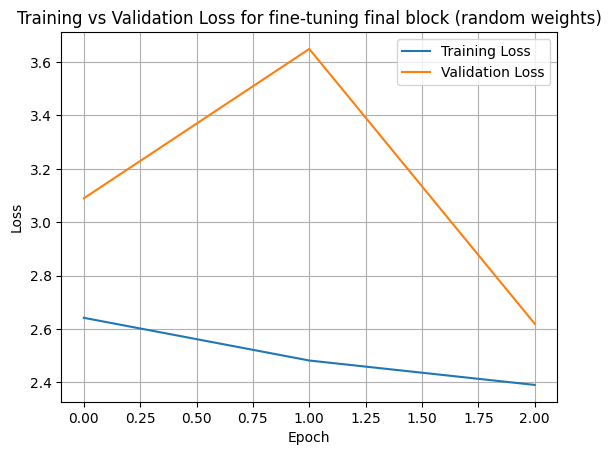

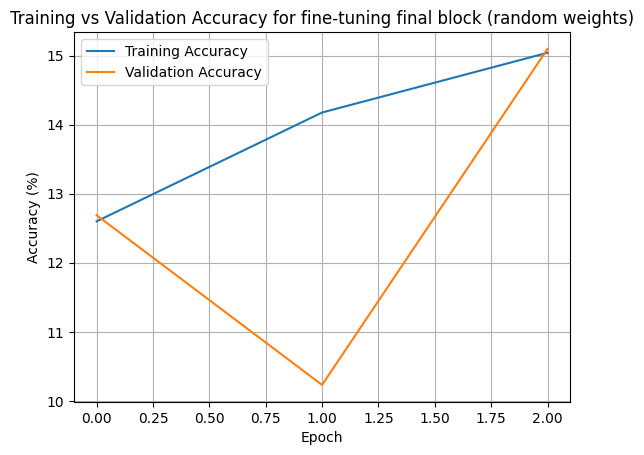

In [ ]:
plt.figure()
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Training vs Validation Loss for fine-tuning final block (random weights)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.figure()
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy for fine-tuning final block (random weights)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid()
plt.legend()

plt.show()